# Taller 1: Abriendo la Caja Negra de las Redes Neuronales

**John González**

*18 de marzo de 2026*

¡Bienvenidos!

El objetivo de este taller es entender **exactamente qué pasa debajo del capó** de una Red Neuronal Profunda. Para ello, nos ensuciaremos las manos y construiremos una desde cero utilizando únicamente matemáticas matriciales en `NumPy`.

Hoy seremos los mecánicos armando el motor pieza por pieza. Esto nos dará la intuición matemática necesaria para que, en la próxima clase, cuando usemos frameworks avanzados como PyTorch, no veamos el código como magia oscura, sino como una extensión de lo que ya dominamos.

In [1]:
import numpy as np
import base64
import matplotlib.pyplot as plt
from IPython.display import Image, display

# ==========================================
# UTILIDADES: Ocultamos la complejidad aquí
# para concentrarnos en el corazón de la red
# ==========================================
def generar_datos_farmacologicos(m=400):
    np.random.seed(42)
    X = np.random.randn(m, 2) * 2
    # Lógica XOR continua (Dilema Farmacológico)
    Y = np.logical_xor(X[:, 0] > 0, X[:, 1] > 0).astype(int)
    # Añadimos un poco de ruido para hacerlo realista
    X += np.random.randn(m, 2) * 0.5
    return X, Y.reshape(m, 1)

def plot_frontera_decision(modelo_predict, X, Y, titulo):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    h = 0.05
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = modelo_predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=Y.ravel(), s=40, cmap=plt.cm.Spectral, edgecolors='k')
    plt.title(titulo)
    plt.xlabel('Dosis Droga A')
    plt.ylabel('Dosis Droga B')
    plt.show()

def mm(graph):
    graphbytes = graph.encode("ascii")
    base64_bytes = base64.b64encode(graphbytes)
    base64_string = base64_bytes.decode("ascii")
    display(Image(url="https://mermaid.ink/img/" + base64_string))


## El Caso de Estudio: El Dilema Farmacológico 💊

Imagina que eres el estadístico principal de un hospital. Tienes dos medicamentos (Droga A y Droga B) para tratar una enfermedad grave. Has descubierto un patrón peculiar:
- Si un paciente recibe dosis altas de la **Droga A (pero no de la B)**, se curará (Clase 1).
- Si recibe dosis altas de la **Droga B (pero no de la A)**, se curará (Clase 1).
- Sin embargo, si recibe dosis altas de **AMBAS**, interactúan de forma tóxica y el paciente sigue enfermo (Clase 0).
- Si no recibe **NINGUNA**, obviamente sigue enfermo (Clase 0).

Este es un problema no lineal clásico conocido como **XOR**. Veamos los datos.

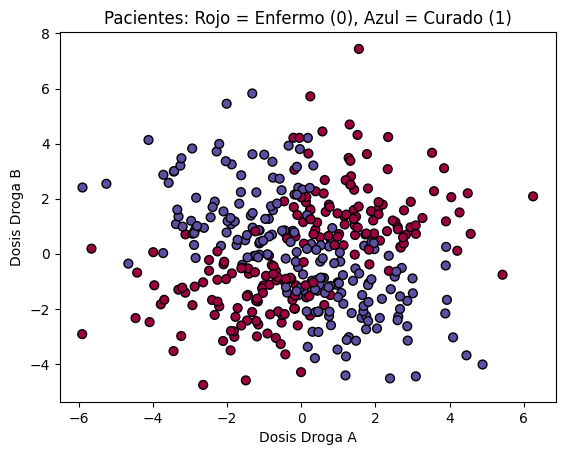

In [16]:
X, Y = generar_datos_farmacologicos(400)

plt.scatter(X[:, 0], X[:, 1], c=Y.ravel(), s=40, cmap=plt.cm.Spectral, edgecolors='k')
plt.title('Pacientes: Rojo = Enfermo (0), Azul = Curado (1)')
plt.xlabel('Dosis Droga A')
plt.ylabel('Dosis Droga B')
plt.show()

## Ejercicio 1: La Función de Activación (La base de todo)

Antes de crear modelos, necesitamos una forma de transformar cualquier número en una probabilidad (un valor entre 0 y 1). Para esto usamos la función **Sigmoide**:

$$ \sigma(z) = \frac{1}{1 + e^{-z}} $$

**💡 TIP PEDAGÓGICO:** En NumPy, la función exponencial $e^{-z}$ se calcula usando `np.exp(-z)`.

In [17]:
def sigmoide(z):
    """
    Calcula la sigmoide de z.
    """
    ### TU CÓDIGO AQUÍ (~1 línea) ###
    a = None
    #################################
    return a

# Prueba de tu función
print("Sigmoide de 0 (Debe ser 0.5):", sigmoide(0))

Sigmoide de 0 (Debe ser 0.5): None


## El límite de la Regresión Logística (Una sola neurona)

Como estadísticos, nuestro primer instinto es usar una Regresión Logística. Curiosamente, en el mundo del Deep Learning, una Regresión Logística es exactamente lo mismo que **una sola neurona artificial**.

**Nota Matemática (`np.dot` vs `@`):**
En NumPy podemos multiplicar matrices con `np.dot(A, B)`. Sin embargo, usaremos el operador `@` (`A @ B`). ¿Por qué? Porque hace que nuestro código se vea idéntico a las ecuaciones algebraicas en el pizarrón.

La ecuación para propagar los datos hacia adelante en una regresión logística es:
$$ Z = X @ W + b $$
$$ A = \sigma(Z) $$

In [18]:
diagrama_lr = """
graph LR
    X1((X1: Droga A)) -->|W1| Z[Z = XW + b]
    X2((X2: Droga B)) -->|W2| Z
    B((Sesgo: b)) -.-> Z

    Z --> A(Activacion: Sigmoide)
    A --> Y((Y_hat: Prob.))

    classDef input fill:#e1f5fe,stroke:#01579b,stroke-width:2px;
    classDef neuron fill:#fff3e0,stroke:#e65100,stroke-width:2px;
    classDef output fill:#e8f5e9,stroke:#1b5e20,stroke-width:2px;

    class X1,X2,B input;
    class Z,A neuron;
    class Y output;
"""
mm(diagrama_lr)

## Ejercicio 2: Propagación hacia adelante en Regresión Logística

**💡 TIP PEDAGÓGICO:** Utiliza el operador `@` para multiplicar la matriz de características `X` por los pesos `W`. Luego pasa el resultado por tu función `sigmoide()`.

In [19]:
def forward_regresion_logistica(X, W, b):
    ### TU CÓDIGO AQUÍ (~2 líneas) ###
    Z = None
    A = None
    #################################
    return A

# ==========================================
# BUCLE DE ENTRENAMIENTO (Regresión Logística)
# ==========================================
m, n_x = X.shape
W_lr = np.random.randn(n_x, 1) * 0.01
b_lr = 0.0
tasa_aprendizaje = 1.2

for i in range(1000):
    A = forward_regresion_logistica(X, W_lr, b_lr)
    if A is None: break # Evitar error si no se ha completado el código

    # Gradientes básicos (Los derivaremos formalmente más adelante)
    dZ = A - Y
    dW = (1/m) * (X.T @ dZ)
    db = (1/m) * np.sum(dZ)

    # Actualización de pesos
    W_lr -= tasa_aprendizaje * dW
    b_lr -= tasa_aprendizaje * db

if A is not None:
    # Veamos qué tan mal le fue (EL ANTI-WOW)
    predicciones_lr = lambda x: (forward_regresion_logistica(x, W_lr, b_lr) > 0.5).astype(int)
    plot_frontera_decision(predicciones_lr, X, Y, 'Falla de la Regresión Logística (Una recta)')

¡Desastroso! La regresión logística intenta trazar un único hiperplano (una línea recta). Es matemáticamente imposible separar un problema XOR con una sola línea.

---
## La Solución: El Perceptrón Multicapa (Red Neuronal)

Para vencer la linealidad, conectaremos varias neuronas formando una **Capa Oculta**. Esta capa extraerá nuevas características espaciales de los datos.

**Nuestra Arquitectura:**
- Capa Entrada: 2 variables ($X_1, X_2$)
- Capa Oculta: 4 neuronas, activación $tanh$
- Capa Salida: 1 neurona, activación $\sigma$ (Sigmoide)

Ecuaciones de propagación hacia adelante (*Forward Propagation*):
$$ Z^{[1]} = X @ W^{[1]} + b^{[1]} $$
$$ A^{[1]} = \tanh(Z^{[1]}) $$
$$ Z^{[2]} = A^{[1]} @ W^{[2]} + b^{[2]} $$
$$ A^{[2]} = \sigma(Z^{[2]}) $$

## Ejercicio 3: Propagación hacia adelante (Red Neuronal)

**💡 TIP PEDAGÓGICO:** Sigue exactamente las 4 ecuaciones de arriba. Para la capa oculta usa `np.tanh()`, y para la salida usa tu función `sigmoide()`.

In [20]:
def forward_propagation_nn(X, W1, b1, W2, b2):
    ### TU CÓDIGO AQUÍ (~4 líneas) ###
    Z1 = None
    A1 = None
    Z2 = None
    A2 = None
    #################################

    # Guardamos los cálculos en caché, los necesitaremos para las derivadas
    cache = {"Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2}
    return A2, cache

## Ejercicio 4: La Función de Costo (Entropía Cruzada Binaria)

Como estadísticos, sabemos que para optimizar un modelo necesitamos medir su error. Usaremos la función de Costo *Log-Loss* (Cross-Entropy):

$$ J = -\frac{1}{m} \sum_{i=1}^{m} \left( y^{(i)} \log(a^{[2](i)}) + (1 - y^{(i)}) \log(1 - a^{[2](i)}) \right) $$

**💡 TIP PEDAGÓGICO:** Usa `np.log()`. En código, la suma se puede hacer multiplicando matrices o usando `np.sum()`. Te dejo la estructura, completa la ecuación matemática interior.

In [21]:
def calcular_costo(A2, Y):
    m = Y.shape[0]

    ### TU CÓDIGO AQUÍ (~1 línea) ###
    # Pista: Y * np.log(...) + (1 - Y) * np.log(...)
    logprobs = None
    #################################

    costo = - (1/m) * np.sum(logprobs)
    return float(np.squeeze(costo))

## Ejercicio 5: Retropropagación (El motor del aprendizaje)

El algoritmo de *Backpropagation* aplica la Regla de la Cadena del cálculo diferencial para responder a la pregunta: *"Si cambio un poquito este peso, ¿el error sube o baja?"*.

Hacer las derivadas matriciales a mano nos tomaría 40 minutos. Aquí tienes las ecuaciones ya derivadas y simplificadas. Tu misión es traducirlas a código:

**Derivadas de la Capa de Salida (Capa 2):**
$$ dZ^{[2]} = A^{[2]} - Y $$
$$ dW^{[2]} = \frac{1}{m} (A^{[1]})^T @ dZ^{[2]} $$
$$ db^{[2]} = \frac{1}{m} \sum dZ^{[2]} $$

**Derivadas de la Capa Oculta (Capa 1):**
$$ dZ^{[1]} = (dZ^{[2]} @ (W^{[2]})^T) * (1 - \tanh^2(Z^{[1]})) $$
$$ dW^{[1]} = \frac{1}{m} X^T @ dZ^{[1]} $$
$$ db^{[1]} = \frac{1}{m} \sum dZ^{[1]} $$

**💡 TIP PEDAGÓGICO:** Recuerda que $(A^{[1]})^T$ en Python se escribe como `A1.T`.

In [22]:
diagrama_nn = """
graph LR
    subgraph Capa de Entrada X
        X1(X1:<br>Droga A)
        X2(X2:<br>Droga B)
    end

    subgraph Capa Oculta A1 [4 Neuronas - Activ: tanh]
        H1(N1<br>z1=W1X+b1<br>a1=tanhz1)
        H2(N2<br>z2=W2X+b2<br>a2=tanhz2)
        H3(N3<br>z3=W3X+b3<br>a3=tanhz3)
        H4(N4<br>z4=W4X+b4<br>a4=tanhz4)
    end

    subgraph Capa de Salida A2 [Out - Activ: Sigmoide]
        O1(Y_hat<br>z_out=W_out.A1+b_out<br>y_pred=sigmaz_out)
    end

    X1 -->|Pesos W| H1 & H2 & H3 & H4
    X2 -->|Pesos W| H1 & H2 & H3 & H4

    H1 & H2 & H3 & H4 -->|Pesos Salida| O1

    classDef input fill:#e1f5fe,stroke:#01579b,stroke-width:2px;
    classDef hidden fill:#fff3e0,stroke:#e65100,stroke-width:2px;
    classDef output fill:#e8f5e9,stroke:#1b5e20,stroke-width:2px;

    class X1,X2 input;
    class H1,H2,H3,H4 hidden;
    class O1 output;
"""
mm(diagrama_nn)

In [23]:
def backward_propagation_nn(cache, X, Y, W2):
    m = X.shape[0]
    A1 = cache['A1']
    A2 = cache['A2']
    Z1 = cache['Z1']

    # Capa 2
    dZ2 = A2 - Y

    ### TU CÓDIGO AQUÍ (~1 línea) ###
    dW2 = None
    #################################
    db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True)

    # Capa 1
    dZ1 = (dZ2 @ W2.T) * (1 - np.power(A1, 2))  # (1 - tanh^2(z))

    ### TU CÓDIGO AQUÍ (~1 línea) ###
    dW1 = None
    #################################
    db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)

    return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}

## Ensamblando el Motor 🌟


Ya creamos los planos del motor. Ahora ejecutaremos el bucle de entrenamiento integrando todas nuestras funciones. Observa cómo el Costo disminuye en cada iteración.

## ¿Dónde están escondidas las 4 neuronas? 🕵️‍♂️
    
Si revisan el código anterior, notarán que **nunca escribimos un bucle `for`** para crear 4 objetos neurona. Entonces, ¿cómo sabe la red cuántas neuronas tiene?,
,
En Deep Learning, la arquitectura está definida **única y exclusivamente por las dimensiones de las matrices de pesos ($W$)**.
El patrón universal y elegante para cualquier capa es:,

👉 **`Dimensión de W = (Número de Entradas, Número de Neuronas)`**

Al multiplicar `X @ W1`:,
- Nuestra matriz `X` tiene **2** columnas (Droga A y B).,
- Nuestra matriz `W1` tiene tamaño **(2, 4)**. *Toma mis 2 entradas, combínalas y genera 4 salidas independientes*.,
- Cada **columna** de la matriz `W1` es, literalmente, una neurona. La computadora procesa las 4 columnas al mismo tiempo gracias a la vectorización matricial.

Observen en el siguiente código el hermoso patrón de conexión: la dimensión de salida de la Capa 1 (`N_H = 4`) se convierte automáticamente en la dimensión de entrada de la Capa 2.

In [24]:
# ==========================================
# 1. DEFINICIÓN DE LA ARQUITECTURA
# ==========================================

N_X = 2  # Entradas (Droga A, Droga B)
N_H = 4  # Neuronas en la Capa Oculta
N_Y = 1  # Neurona en la Capa de Salida (Probabilidad)

# ==========================================
# 2. INICIALIZACIÓN DE PARÁMETROS
# ==========================================
np.random.seed(3),

# Capa Oculta: Conecta N_X con N_H
W1 = np.random.randn(N_X, N_H) * 0.01  # Dimensión: (2, 4)
b1 = np.zeros((1, N_H))                # Dimensión: (1, 4)

# Capa de Salida: Conecta N_H con N_Y,
W2 = np.random.randn(N_H, N_Y) * 0.01  # Dimensión: (4, 1)
b2 = np.zeros((1, N_Y))                # Dimensión: (1, 1)

In [25]:
# ==========================================
# 3. ENSAMBLANDO EL MOTOR
# ==========================================

tasa_aprendizaje = 1.2
epocas = 5000

for i in range(epocas):
    # 1. Propagación hacia adelante
    A2, cache = forward_propagation_nn(X, W1, b1, W2, b2)
    if A2 is None: break # Evitar error si el código está incompleto

    # 2. Calcular costo
    costo = calcular_costo(A2, Y)

    # 3. Retropropagación (Backpropagation)
    gradientes = backward_propagation_nn(cache, X, Y, W2)

    # 4. Actualización de pesos (Descenso del Gradiente)
    W1 -= tasa_aprendizaje * gradientes["dW1"]
    b1 -= tasa_aprendizaje * gradientes["db1"]
    W2 -= tasa_aprendizaje * gradientes["dW2"]
    b2 -= tasa_aprendizaje * gradientes["db2"]

    if i % 1000 == 0:
        print(f"Costo en la época {i}: {costo:.4f}")

# ¡Momento de la verdad! Graficamos la nueva frontera de decisión
if A2 is not None:
    predicciones_nn = lambda x: (forward_propagation_nn(x, W1, b1, W2, b2)[0] > 0.5).astype(int)
    plot_frontera_decision(predicciones_nn, X, Y, '¡La magia de la Red Neuronal (No-Linealidad)!')

## Ejercicio 6: Jugando a ser el Arquitecto (Experimentación) 🛠️

Ya vimos que con `N_H = 4` (4 neuronas en la capa oculta) la red logra resolver el problema no lineal. Pero, ¿qué pasa si alteramos la arquitectura?

He encapsulado nuestro bucle de entrenamiento en una función llamada `experimentar_arquitectura()`. Tu misión es ejecutarla con diferentes tamaños de capa oculta y observar cómo cambia la frontera de decisión.

**Tu reto:**
1. Prueba con `N_H = 1`. ¿A qué modelo estadístico clásico se parece el resultado?
2. Prueba con `N_H = 2`. ¿Es suficiente para resolver el problema XOR?
3. Prueba con `N_H = 20`. ¿Qué le pasa a la frontera de decisión? ¿Se ve más "natural" o empieza a memorizar el ruido (Overfitting)?

In [26]:
def experimentar_arquitectura(N_H_prueba, epocas=3000):
    print(f"\n--- Entrenando modelo con {N_H_prueba} neuronas ocultas ---")
    N_X = 2
    N_Y = 1

    # Inicialización
    np.random.seed(3)
    W1 = np.random.randn(N_X, N_H_prueba) * 0.01
    b1 = np.zeros((1, N_H_prueba))
    W2 = np.random.randn(N_H_prueba, N_Y) * 0.01
    b2 = np.zeros((1, N_Y))

    tasa_aprendizaje = 1.2

    # Bucle
    for i in range(epocas):
        A2, cache = forward_propagation_nn(X, W1, b1, W2, b2)
        gradientes = backward_propagation_nn(cache, X, Y, W2)

        W1 -= tasa_aprendizaje * gradientes["dW1"]
        b1 -= tasa_aprendizaje * gradientes["db1"]
        W2 -= tasa_aprendizaje * gradientes["dW2"]
        b2 -= tasa_aprendizaje * gradientes["db2"]

    # Visualización
    predicciones = lambda x: (forward_propagation_nn(x, W1, b1, W2, b2)[0] > 0.5).astype(int)
    plot_frontera_decision(predicciones, X, Y, f'Arquitectura: N_H = {N_H_prueba}')

# ==========================================
# ¡ZONA DE EXPERIMENTACIÓN!
# Cambia los valores de N_H y ejecuta la celda
# ==========================================

### TU CÓDIGO AQUÍ ###

# 1. Prueba con 1 neurona
# experimentar_arquitectura(N_H_prueba=1)

# 2. Prueba con 2 neuronas
# experimentar_arquitectura(N_H_prueba=2)

# 3. Prueba con 20 neuronas
# experimentar_arquitectura(N_H_prueba=20)

#################################

### Análisis de Resultados (Doble clic para editar)

Escribe aquí tus conclusiones tras observar las diferentes arquitecturas:

*   **Con N_H = 1:** *(Escribe qué observaste. ¿Por qué crees que falló?)*
*   **Con N_H = 2:** *(Escribe qué observaste. ¿Logró capturar las dos diagonales?)*
*   **Con N_H = 20:** *(Escribe qué observaste. ¿La frontera de decisión es más suave o empieza a hacer formas raras para capturar puntos atípicos?)*

**Conclusión clave:** El número de neuronas ocultas es un **hiperparámetro**. Define la "capacidad" del modelo. Muy pocas neuronas causan *Underfitting* (Alto Sesgo/Bias), demasiadas pueden causar *Overfitting* (Alta Varianza).

## Reflexión Final

**¡Felicidades!** Acaban de construir una Inteligencia Artificial capaz de vencer la linealidad, resolviendo el dilema farmacológico con una precisión asombrosa. Y lo mejor: comprenden perfectamente las matemáticas matriciales que permitieron que esa frontera de decisión se "doblara".

**Sin embargo...**

Miren cuánto código tuvimos que escribir. Tuvimos que calcular matemáticamente la derivada de $\tanh$ y programar la regla de la cadena manualmente. Imaginen hacer esto para una red de 100 capas que analice miles de variables o imágenes. Sería una pesadilla matemática y de *código espagueti*.

**¿La solución?**
En la próxima clase abandonaremos los cálculos manuales de derivadas. Adoptaremos la Programación Orientada a Objetos (POO) y utilizaremos los súper-poderes de los grafos computacionales dinámicos (*Autograd*) con el framework más poderoso de la actualidad: **PyTorch**.